# OBGPU Drift Comparison

This notebook compares the fast `1`-rank GPU mode against the parity-preserving `2`-rank GPU mode using existing benchmark artifacts.


In [1]:
from pathlib import Path
import json
import pickle
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-darkgrid")

ROOT = Path("/home/alek/OlfactoryBulb")
FAST_DIR = ROOT / "results/benchmarks/perf_gpu_lfp_r1_perm2_1800ms_v1"
PARITY_DIR = ROOT / "results/benchmarks/perf_gpu_lfp_r2_perm2_1800ms_v1"

def load_json(path):
    with open(path) as f:
        return json.load(f)

def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

def as_array(values):
    return np.asarray(values, dtype=float)

def input_map(items):
    return {label: as_array(times) for label, times in items}

def soma_map(items):
    return {label: (as_array(times), as_array(values)) for label, times, values in items}

def lfp_map(path):
    t, v = load_pickle(path)
    return as_array(t), as_array(v)

def cell_type(label):
    label = label[2:] if label.startswith("h.") else label
    return label.split("[", 1)[0]

def max_abs(values):
    values = as_array(values)
    if values.size == 0:
        return 0.0
    return float(np.max(np.abs(values)))

def diff_stats(diff):
    diff = as_array(diff)
    if diff.size == 0:
        return {"max_abs": 0.0, "rms": 0.0, "mean": 0.0, "final": 0.0}
    return {
        "max_abs": float(np.max(np.abs(diff))),
        "rms": float(np.sqrt(np.mean(diff ** 2))),
        "mean": float(np.mean(diff)),
        "final": float(diff[-1]),
    }

def aligned_diff(a_t, a_v, b_t, b_v):
    n = min(len(a_t), len(a_v), len(b_t), len(b_v))
    return a_t[:n], a_v[:n] - b_v[:n]


In [2]:
fast_summary = load_json(FAST_DIR / "summary.json")
parity_summary = load_json(PARITY_DIR / "summary.json")

fast_inputs = input_map(load_pickle(FAST_DIR / "input_times.pkl"))
parity_inputs = input_map(load_pickle(PARITY_DIR / "input_times.pkl"))
fast_soma = soma_map(load_pickle(FAST_DIR / "soma_vs.pkl"))
parity_soma = soma_map(load_pickle(PARITY_DIR / "soma_vs.pkl"))
fast_lfp_t, fast_lfp_v = lfp_map(FAST_DIR / "lfp.pkl")
parity_lfp_t, parity_lfp_v = lfp_map(PARITY_DIR / "lfp.pkl")

common_inputs = sorted(set(fast_inputs) & set(parity_inputs))
common_soma = sorted(set(fast_soma) & set(parity_soma))

input_diffs = []
for label in common_inputs:
    diff = fast_inputs[label] - parity_inputs[label]
    input_diffs.append((label, max_abs(diff)))

soma_diffs = []
for label in common_soma:
    ft, fv = fast_soma[label]
    pt, pv = parity_soma[label]
    t, diff = aligned_diff(ft, fv, pt, pv)
    row = diff_stats(diff)
    row["label"] = label
    row["cell_type"] = cell_type(label)
    row["time"] = t
    row["diff"] = diff
    row["fast"] = fv[: len(t)]
    row["parity"] = pv[: len(t)]
    soma_diffs.append(row)

lfp_t, lfp_diff = aligned_diff(fast_lfp_t, fast_lfp_v, parity_lfp_t, parity_lfp_v)
lfp_stats = diff_stats(lfp_diff)
worst_soma = max(soma_diffs, key=lambda row: row["max_abs"])
speedup = parity_summary["timing_seconds"]["total_max_rank"] / fast_summary["timing_seconds"]["total_max_rank"]

display(Markdown(f"""
## Run Summary

| Metric | Fast `1`-rank GPU | Parity `2`-rank GPU |
| --- | ---: | ---: |
| total time (s) | {fast_summary['timing_seconds']['total_max_rank']:.3f} | {parity_summary['timing_seconds']['total_max_rank']:.3f} |
| run time (s) | {fast_summary['timing_seconds']['run_max_rank']:.3f} | {parity_summary['timing_seconds']['run_max_rank']:.3f} |
| build time (s) | {fast_summary['timing_seconds']['build_max_rank']:.3f} | {parity_summary['timing_seconds']['build_max_rank']:.3f} |
| save time (s) | {fast_summary['timing_seconds']['save_max_rank']:.3f} | {parity_summary['timing_seconds']['save_max_rank']:.3f} |
| max input drift | {max((v for _, v in input_diffs), default=0.0):.3e} | {max((v for _, v in input_diffs), default=0.0):.3e} |
| max LFP drift | {lfp_stats['max_abs']:.3e} | {lfp_stats['max_abs']:.3e} |
| worst soma drift | {worst_soma['max_abs']:.3e} | {worst_soma['max_abs']:.3e} |

Fast-mode wall-clock speedup over parity mode: **{speedup:.3f}x**.

Worst soma drift: **{worst_soma['label']}**.
"""))



## Run Summary

| Metric | Fast `1`-rank GPU | Parity `2`-rank GPU |
| --- | ---: | ---: |
| total time (s) | 429.863 | 886.116 |
| run time (s) | 394.294 | 873.951 |
| build time (s) | 34.009 | 10.355 |
| save time (s) | 1.560 | 1.810 |
| max input drift | 0.000e+00 | 0.000e+00 |
| max LFP drift | 5.999e-02 | 5.999e-02 |
| worst soma drift | 1.124e+02 | 1.124e+02 |

Fast-mode wall-clock speedup over parity mode: **2.061x**.

Worst soma drift: **GC5[22].soma**.


Text(0.5, 0, 'Time (ms)')

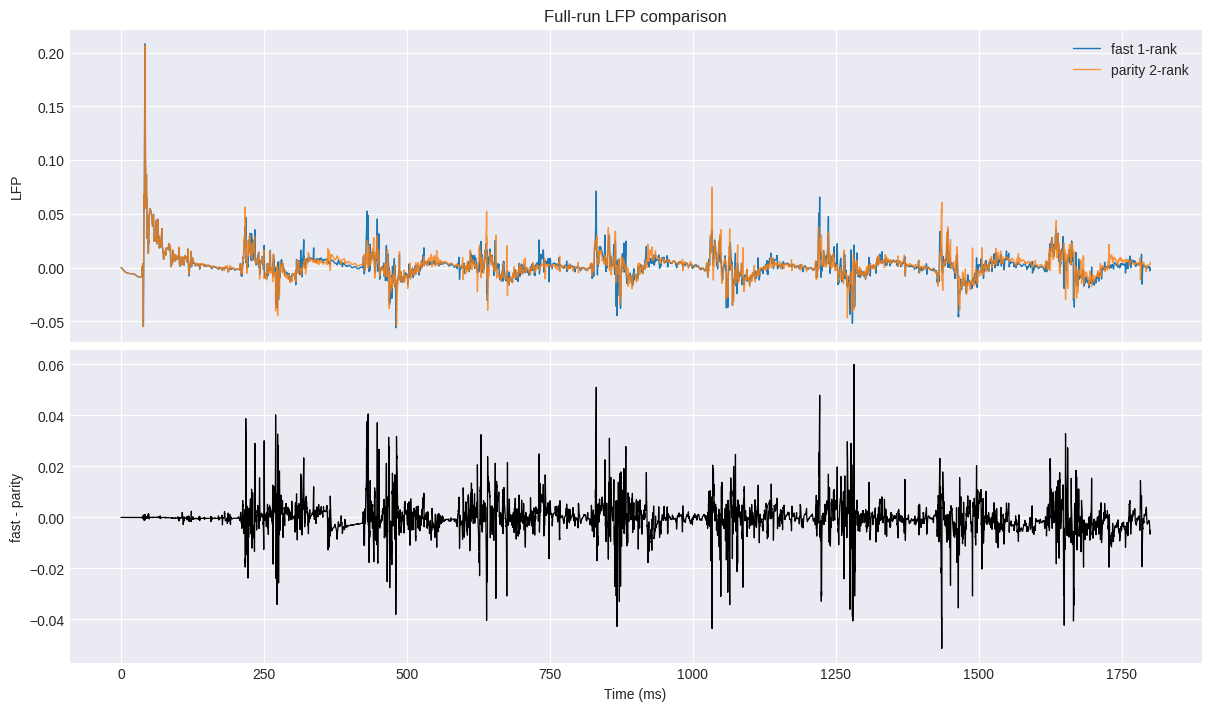

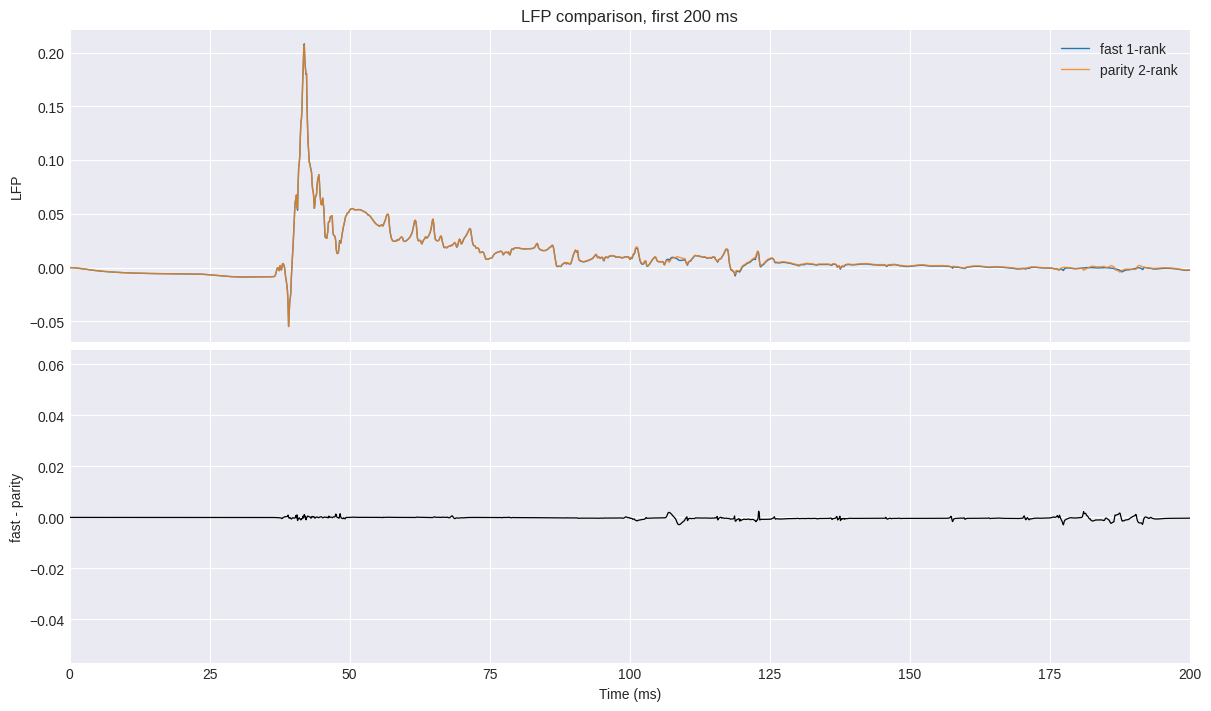

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)
axes[0].plot(lfp_t, fast_lfp_v[: len(lfp_t)], lw=1.0, label="fast 1-rank")
axes[0].plot(lfp_t, parity_lfp_v[: len(lfp_t)], lw=1.0, alpha=0.8, label="parity 2-rank")
axes[0].set_ylabel("LFP")
axes[0].set_title("Full-run LFP comparison")
axes[0].legend(loc="best")
axes[1].plot(lfp_t, lfp_diff, color="black", lw=0.9)
axes[1].set_ylabel("fast - parity")
axes[1].set_xlabel("Time (ms)")

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)
axes[0].plot(lfp_t, fast_lfp_v[: len(lfp_t)], lw=1.0, label="fast 1-rank")
axes[0].plot(lfp_t, parity_lfp_v[: len(lfp_t)], lw=1.0, alpha=0.8, label="parity 2-rank")
axes[0].set_xlim(0, 200)
axes[0].set_ylabel("LFP")
axes[0].set_title("LFP comparison, first 200 ms")
axes[0].legend(loc="best")
axes[1].plot(lfp_t, lfp_diff, color="black", lw=0.9)
axes[1].set_xlim(0, 200)
axes[1].set_ylabel("fast - parity")
axes[1].set_xlabel("Time (ms)")


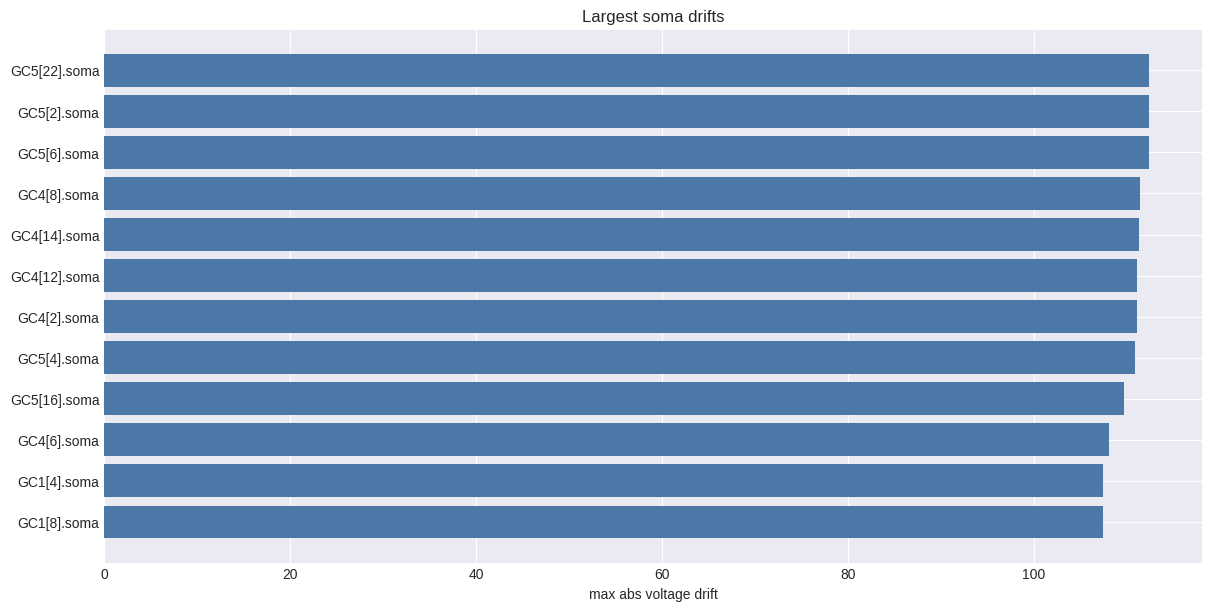

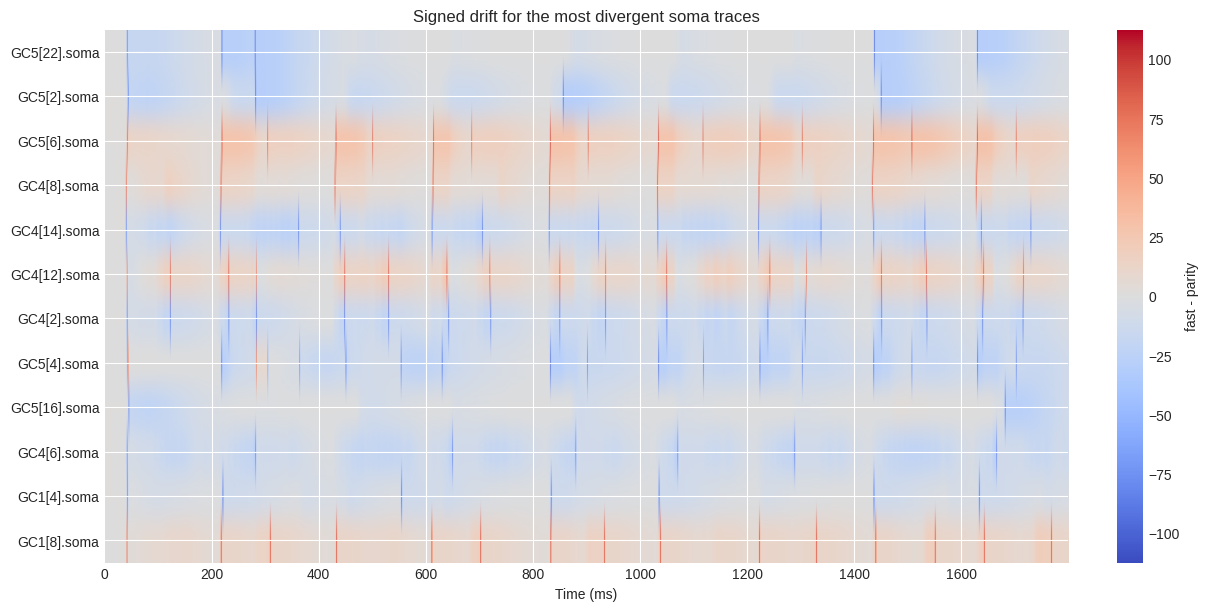

In [4]:
top = sorted(soma_diffs, key=lambda row: row["max_abs"], reverse=True)[:12]
labels = [row["label"] for row in top][::-1]
values = [row["max_abs"] for row in top][::-1]

fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
ax.barh(labels, values, color="#4c78a8")
ax.set_xlabel("max abs voltage drift")
ax.set_title("Largest soma drifts")

heat_rows = top[::-1]
heat = np.vstack([row["diff"] for row in heat_rows])
heat_t = heat_rows[0]["time"]
amp = float(np.max(np.abs(heat))) if heat.size else 1.0

fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
im = ax.imshow(
    heat,
    aspect="auto",
    cmap="coolwarm",
    vmin=-amp,
    vmax=amp,
    extent=[heat_t[0], heat_t[-1], 0, len(heat_rows)],
    origin="lower",
)
ax.set_yticks(np.arange(len(heat_rows)) + 0.5)
ax.set_yticklabels([row["label"] for row in heat_rows])
ax.set_xlabel("Time (ms)")
ax.set_title("Signed drift for the most divergent soma traces")
fig.colorbar(im, ax=ax, label="fast - parity")


/tmp/ipykernel_2565357/3013116872.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showfliers=False)


ValueError: Dimensions of labels and X must be compatible

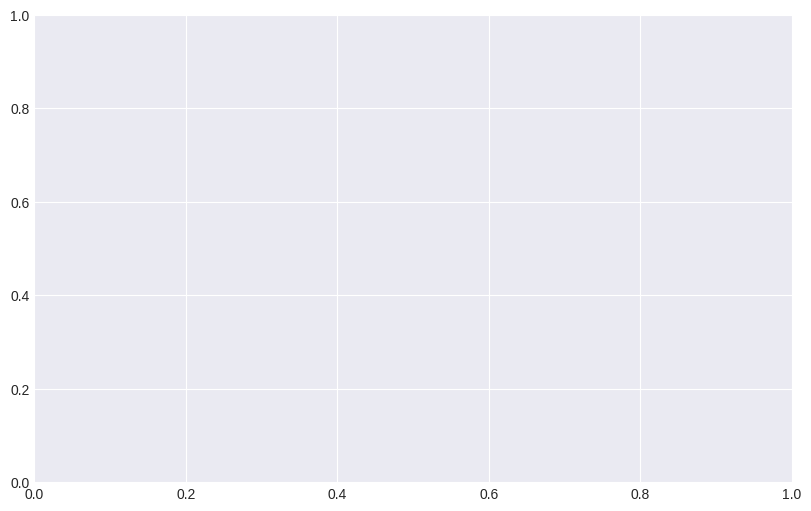

In [5]:
by_type = defaultdict(list)
for row in soma_diffs:
    by_type[row["cell_type"]].append(row)

order = [name for name in ["MC", "TC", "GC"] if name in by_type]
data = [[row["max_abs"] for row in by_type[name]] for name in order]

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
ax.boxplot(data, labels=order, showfliers=False)
ax.set_yscale("log")
ax.set_ylabel("max abs voltage drift")
ax.set_title("Drift distribution by cell type")

fig, axes = plt.subplots(len(order), 1, figsize=(12, 8), sharex=True, constrained_layout=True)
if len(order) == 1:
    axes = [axes]

for ax, name in zip(axes, order):
    row = max(by_type[name], key=lambda item: item["max_abs"])
    ax.plot(row["time"], row["fast"], lw=1.0, label="fast 1-rank")
    ax.plot(row["time"], row["parity"], lw=1.0, alpha=0.8, label="parity 2-rank")
    ax.set_ylabel(name)
    ax.set_title(f"Worst {name} trace: {row['label']}")
    ax.legend(loc="best")

axes[-1].set_xlabel("Time (ms)")
